## Cell 1: Imports & Config

In [30]:
# --- 01_data_audit.ipynb ---
import torch
import os
import glob
import random
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from tqdm.auto import tqdm

# Load config
from src.config import CONFIG

# For nicer plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('ggplot')

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Paths from config
base = Path("F:/projects/hirdl/FedSSL_Paper")
data_root = base / "data_set/kits_2d_splitted"

train_img_dir = Path(CONFIG['data']['train_image_dir'])
train_mask_dir = Path(CONFIG['data']['train_mask_dir'])
val_img_dir   = Path(CONFIG['data']['val_image_dir'])
val_mask_dir   = Path(CONFIG['data']['val_mask_dir'])
test_img_dir  = Path(CONFIG['data']['test_image_dir'])
test_mask_dir = Path(CONFIG['data']['test_mask_dir'])

print("\nChecking paths:")
for d in [train_img_dir, train_mask_dir, val_img_dir, val_mask_dir, test_img_dir, test_mask_dir]:
    print(f"{d}: exists = {d.exists()}, files = {len(list(d.glob('*.png')))}")

PyTorch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Ti

Checking paths:
F:\projects\hirdl\FedSSL_Paper\data_set\kits_2d_splitted\train\images: exists = True, files = 11860
F:\projects\hirdl\FedSSL_Paper\data_set\kits_2d_splitted\train\masks: exists = True, files = 11860
F:\projects\hirdl\FedSSL_Paper\data_set\kits_2d_splitted\val\images: exists = True, files = 2309
F:\projects\hirdl\FedSSL_Paper\data_set\kits_2d_splitted\val\masks: exists = True, files = 2309
F:\projects\hirdl\FedSSL_Paper\data_set\kits_2d_splitted\test\images: exists = True, files = 3808
F:\projects\hirdl\FedSSL_Paper\data_set\kits_2d_splitted\test\masks: exists = True, files = 3808


## Cell 2: Collect file pairs & basic stats

In [9]:
def get_pairs(img_dir, mask_dir):
    img_files = sorted(glob.glob(str(img_dir / "*.png")))
    mask_files = sorted(glob.glob(str(mask_dir / "*.png")))
    
    # Assume filenames are identical
    img_names = {Path(f).name for f in img_files}
    mask_names = {Path(f).name for f in mask_files}
    
    common = img_names & mask_names
    missing_img = mask_names - img_names
    missing_mask = img_names - mask_names
    
    print(f"\nSplit: {img_dir.parent.name}")
    print(f"Images: {len(img_files)} | Masks: {len(mask_files)}")
    print(f"Paired: {len(common)} | Missing images: {len(missing_img)} | Missing masks: {len(missing_mask)}")
    
    if len(common) == 0:
        print("!!! NO MATCHING FILENAMES FOUND !!!")
        print("First 5 images:", img_files[:5])
        print("First 5 masks: ", mask_files[:5])
    
    return sorted(list(common)), img_files, mask_files


train_pairs, _, _ = get_pairs(train_img_dir, train_mask_dir)
val_pairs,   _, _ = get_pairs(val_img_dir,   val_mask_dir)
test_pairs,  _, _ = get_pairs(test_img_dir,  test_mask_dir)


Split: train
Images: 11860 | Masks: 11860
Paired: 11860 | Missing images: 0 | Missing masks: 0

Split: val
Images: 2309 | Masks: 2309
Paired: 2309 | Missing images: 0 | Missing masks: 0

Split: test
Images: 3808 | Masks: 3808
Paired: 3808 | Missing images: 0 | Missing masks: 0


## Cell 3: Inspect sample image + mask + derive label


--- Train sample 0 ---
File: case_00000_axial_291.png
Image shape: (512, 512), dtype: uint8
Mask  shape: (512, 512), dtype: uint8
Mask unique values: [  0 127 255]
Tumor present: False


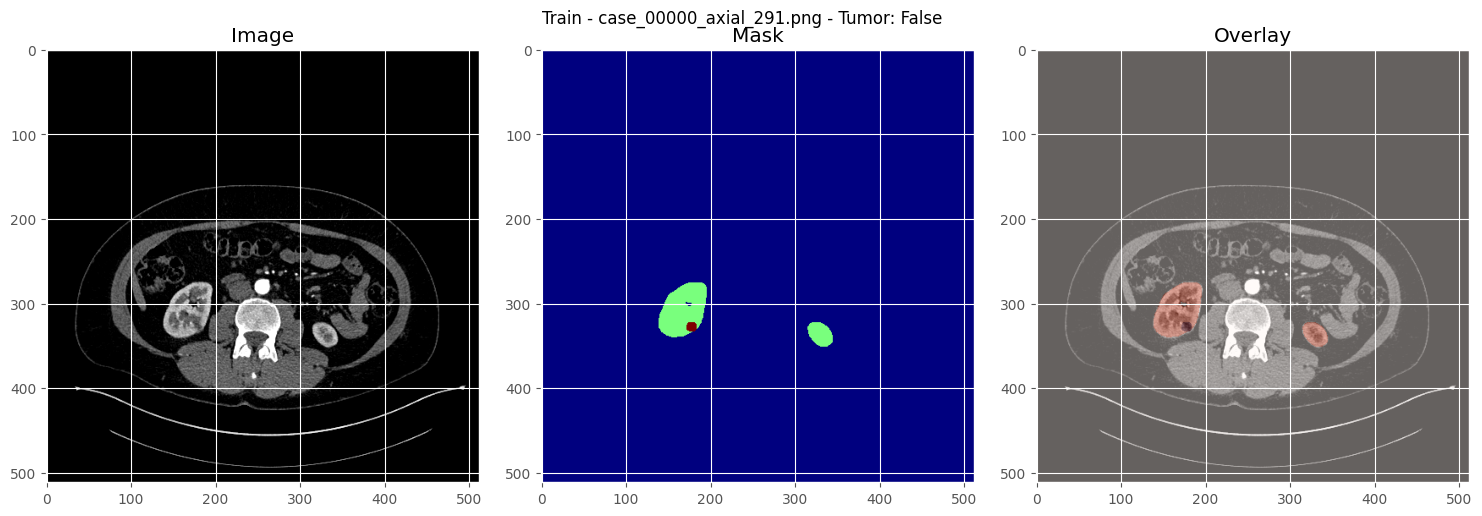

(False, array([  0, 127, 255], dtype=uint8))

In [16]:
def inspect_sample(split_name, img_dir, mask_dir, pair_list, idx=0):
    if not pair_list:
        print("No pairs available")
        return
    
    fname = pair_list[idx]
    img_path = img_dir / fname
    mask_path = mask_dir / fname
    
    img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    
    print(f"\n--- {split_name} sample {idx} ---")
    print(f"File: {fname}")
    print(f"Image shape: {img.shape if img is not None else 'FAILED'}, dtype: {img.dtype if img is not None else 'N/A'}")
    print(f"Mask  shape: {mask.shape if mask is not None else 'FAILED'}, dtype: {mask.dtype if mask is not None else 'N/A'}")
    
    if mask is not None:
        unique_vals = np.unique(mask)
        print(f"Mask unique values: {unique_vals}")
        has_tumor = 2 in unique_vals if len(unique_vals) > 1 else False
        print(f"Tumor present: {has_tumor}")
    
    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img, cmap='gray' if len(img.shape)==2 else None)
    axes[0].set_title("Image")
    axes[1].imshow(mask, cmap='jet')
    axes[1].set_title("Mask")
    axes[2].imshow(img, cmap='gray' if len(img.shape)==2 else None)
    if mask is not None:
        axes[2].imshow(mask, alpha=0.4, cmap='Reds')
    axes[2].set_title("Overlay")
    plt.suptitle(f"{split_name} - {fname} - Tumor: {has_tumor}")
    plt.tight_layout()
    plt.show()
    
    return has_tumor, unique_vals


# Test first sample from train
inspect_sample("Train", train_img_dir, train_mask_dir, train_pairs, idx=0)

In [17]:
def inspect_sample(split_name, img_dir, mask_dir, pair_list, idx):
    if idx >= len(pair_list):
        print("Index out of range")
        return
    
    fname = pair_list[idx]
    img_path = img_dir / fname
    mask_path = mask_dir / fname
    
    img = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
    
    if mask is None or img is None:
        print("Failed to load")
        return
    
    unique = np.unique(mask)
    tumor_pixels = np.sum(mask == 255)
    kidney_pixels = np.sum(mask == 127)
    bg_pixels = np.sum(mask == 0)
    
    print(f"\n--- {split_name} sample idx={idx} ---")
    print(f"File: {fname}")
    print(f"Shape: {img.shape}, Mask unique: {unique}")
    print(f"Pixel counts: BG={bg_pixels}, Kidney={kidney_pixels}, Tumor={tumor_pixels}")
    print(f"Tumor present (any 255): {tumor_pixels > 0}")
    
    # Plot with better contrast
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title("CT Image")
    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title("Raw Mask (0/127/255)")
    axes[2].imshow(mask == 255, cmap='Reds')
    axes[2].set_title("Tumor pixels only (==255)")
    axes[3].imshow(img, cmap='gray')
    axes[3].imshow(mask == 255, alpha=0.5, cmap='Reds')
    axes[3].set_title("Overlay tumor")
    plt.suptitle(f"{fname} - Tumor pixels: {tumor_pixels}")
    plt.tight_layout()
    plt.show()
    
    return tumor_pixels > 0

In [18]:
# Assuming you have train_df from previous run
no_tumor = train_df[train_df['has_tumor'] == False]
print(f"Slices with NO tumor pixels (255): {len(no_tumor)} / {len(train_df)}")
if len(no_tumor) > 0:
    print("Sample no-tumor filenames:", no_tumor['filename'].head(5).tolist())
else:
    print("ZERO slices without 255 pixels → masks likely corrupted or all have artifacts")

Slices with NO tumor pixels (255): 0 / 11860
ZERO slices without 255 pixels → masks likely corrupted or all have artifacts


In [19]:
def extract_case_id(fname):
    # case_00000_axial_291.png → 'case_00000'
    return fname.split('_axial')[0]  # safe split

train_cases = set(extract_case_id(f) for f in train_pairs)
val_cases   = set(extract_case_id(f) for f in val_pairs)
test_cases  = set(extract_case_id(f) for f in test_pairs)

print(f"Unique cases - Train: {len(train_cases)}, Val: {len(val_cases)}, Test: {len(test_cases)}")
print(f"Overlap train-val: {len(train_cases & val_cases)}")
print(f"Overlap train-test: {len(train_cases & test_cases)}")

Unique cases - Train: 4347, Val: 823, Test: 1579
Overlap train-val: 0
Overlap train-test: 0


## Cell 4: Quick statistics on all slices (this may take 1–3 minutes)

In [20]:
import numpy as np
from tqdm.auto import tqdm
import pandas as pd

def compute_label_statistics(img_dir, mask_dir, pairs, split_name, min_tumor_pixels=50):
    stats = []
    for fname in tqdm(pairs, desc=f"Processing {split_name}"):
        mask_path = mask_dir / fname
        mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)
        if mask is None:
            continue
        tumor_pixels = np.sum(mask == 255)
        has_tumor = tumor_pixels >= min_tumor_pixels  # <--- key fix
        unique = np.unique(mask)
        stats.append({
            "filename": fname,
            "has_tumor": has_tumor,
            "tumor_pixel_count": tumor_pixels,
            "unique_vals": str(unique.tolist())
        })
    
    df = pd.DataFrame(stats)
    counts = df["has_tumor"].value_counts(normalize=True) * 100
    print(f"\n{split_name} statistics (min {min_tumor_pixels} tumor pixels):")
    print(f"Total slices: {len(df)}")
    print(f"Tumor present (>= {min_tumor_pixels} px): {counts.get(True, 0):.2f}% | Absent: {counts.get(False, 0):.2f}%")
    print(f"Avg tumor pixels (positive only): {df[df['has_tumor']]['tumor_pixel_count'].mean():.1f}")
    print(f"Slices with tiny artifacts only (< {min_tumor_pixels}): {len(df[(df['tumor_pixel_count'] > 0) & (~df['has_tumor'])])}")
    
    return df

# Test different thresholds to find best
for thresh in [10, 50, 100, 200]:
    print(f"\n--- Threshold {thresh} ---")
    _ = compute_label_statistics(train_img_dir, train_mask_dir, train_pairs, "Train", min_tumor_pixels=thresh)


--- Threshold 10 ---


Processing Train:   0%|          | 0/11860 [00:00<?, ?it/s]


Train statistics (min 10 tumor pixels):
Total slices: 11860
Tumor present (>= 10 px): 100.00% | Absent: 0.00%
Avg tumor pixels (positive only): 3546.7
Slices with tiny artifacts only (< 10): 0

--- Threshold 50 ---


Processing Train:   0%|          | 0/11860 [00:00<?, ?it/s]


Train statistics (min 50 tumor pixels):
Total slices: 11860
Tumor present (>= 50 px): 100.00% | Absent: 0.00%
Avg tumor pixels (positive only): 3546.7
Slices with tiny artifacts only (< 50): 0

--- Threshold 100 ---


Processing Train:   0%|          | 0/11860 [00:00<?, ?it/s]


Train statistics (min 100 tumor pixels):
Total slices: 11860
Tumor present (>= 100 px): 100.00% | Absent: 0.00%
Avg tumor pixels (positive only): 3546.7
Slices with tiny artifacts only (< 100): 0

--- Threshold 200 ---


Processing Train:   0%|          | 0/11860 [00:00<?, ?it/s]


Train statistics (min 200 tumor pixels):
Total slices: 11860
Tumor present (>= 200 px): 94.30% | Absent: 5.70%
Avg tumor pixels (positive only): 3752.0
Slices with tiny artifacts only (< 200): 676


# ----------------

# Milestone 1

## Cell 1: Imports & Setup

In [29]:
import torch
import os
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from torchvision import transforms

from src.config import CONFIG

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Ti


## Cell 1 — Imports + device helper

In [1]:
from pathlib import Path
import random, re, json
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    # (Optional future-proofing for Mac)
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
print("Device:", DEVICE)

Device: cuda


## Cell 2 — Point to your dataset root

In [2]:
DATA_ROOT = Path(r"F:\projects\hirdl\FedSSL_Paper\data_set\kits_2d_splitted")

assert DATA_ROOT.exists(), f"DATA_ROOT not found: {DATA_ROOT}"
print("DATA_ROOT OK:", DATA_ROOT)

DATA_ROOT OK: F:\projects\hirdl\FedSSL_Paper\data_set\kits_2d_splitted


## Cell 3 — Robust split directory resolution

In [3]:
SPLITS = ["train", "val", "test"]

def find_split_dir(root: Path, split: str) -> Path:
    d = root / split
    if not d.exists():
        raise FileNotFoundError(f"Missing split folder: {d}")
    return d

def find_subdir(parent: Path, candidates):
    for name in candidates:
        p = parent / name
        if p.exists():
            return p
    # fallback: search one level deep
    for p in parent.glob("*"):
        if p.is_dir() and p.name.lower() in [c.lower() for c in candidates]:
            return p
    raise FileNotFoundError(f"Could not find any of {candidates} under {parent}")

def resolve_split_paths(root: Path):
    info = {}
    for split in SPLITS:
        sdir = find_split_dir(root, split)
        img_dir = find_subdir(sdir, ["image", "images"])
        msk_dir = find_subdir(sdir, ["mask", "masks"])
        info[split] = {"split_dir": sdir, "images": img_dir, "masks": msk_dir}
    return info

paths = resolve_split_paths(DATA_ROOT)
paths

{'train': {'split_dir': WindowsPath('F:/projects/hirdl/FedSSL_Paper/data_set/kits_2d_splitted/train'),
  'images': WindowsPath('F:/projects/hirdl/FedSSL_Paper/data_set/kits_2d_splitted/train/images'),
  'masks': WindowsPath('F:/projects/hirdl/FedSSL_Paper/data_set/kits_2d_splitted/train/masks')},
 'val': {'split_dir': WindowsPath('F:/projects/hirdl/FedSSL_Paper/data_set/kits_2d_splitted/val'),
  'images': WindowsPath('F:/projects/hirdl/FedSSL_Paper/data_set/kits_2d_splitted/val/images'),
  'masks': WindowsPath('F:/projects/hirdl/FedSSL_Paper/data_set/kits_2d_splitted/val/masks')},
 'test': {'split_dir': WindowsPath('F:/projects/hirdl/FedSSL_Paper/data_set/kits_2d_splitted/test'),
  'images': WindowsPath('F:/projects/hirdl/FedSSL_Paper/data_set/kits_2d_splitted/test/images'),
  'masks': WindowsPath('F:/projects/hirdl/FedSSL_Paper/data_set/kits_2d_splitted/test/masks')}}

## Cell 4 — Pair images ↔ masks by filename stem

In [4]:
def list_pngs(folder: Path):
    return sorted([p for p in folder.rglob("*.png") if p.is_file()])

def stem_key(p: Path):
    return p.stem  # if needed later: normalize case, remove suffix patterns, etc.

def build_pairs(img_dir: Path, msk_dir: Path):
    imgs = list_pngs(img_dir)
    msks = list_pngs(msk_dir)

    img_map = {}
    for p in imgs:
        img_map.setdefault(stem_key(p), []).append(p)

    msk_map = {}
    for p in msks:
        msk_map.setdefault(stem_key(p), []).append(p)

    keys = sorted(set(img_map) | set(msk_map))
    pairs = []
    missing_img = []
    missing_msk = []
    multi_img = []
    multi_msk = []

    for k in keys:
        i_list = img_map.get(k, [])
        m_list = msk_map.get(k, [])
        if len(i_list) == 0:
            missing_img.append(k)
            continue
        if len(m_list) == 0:
            missing_msk.append(k)
            continue
        if len(i_list) > 1:
            multi_img.append(k)
        if len(m_list) > 1:
            multi_msk.append(k)
        pairs.append((i_list[0], m_list[0]))

    report = {
        "num_imgs": len(imgs),
        "num_msks": len(msks),
        "num_pairs": len(pairs),
        "missing_img_keys": len(missing_img),
        "missing_msk_keys": len(missing_msk),
        "multi_img_keys": len(multi_img),
        "multi_msk_keys": len(multi_msk),
    }
    return pairs, report

split_pairs = {}
split_reports = {}

for split in SPLITS:
    img_dir = paths[split]["images"]
    msk_dir = paths[split]["masks"]
    pairs, report = build_pairs(img_dir, msk_dir)
    split_pairs[split] = pairs
    split_reports[split] = report

pd.DataFrame(split_reports).T

,num_imgs,num_msks,num_pairs,missing_img_keys,missing_msk_keys,multi_img_keys,multi_msk_keys
train,11860,11860,11860,0,0,0,0
val,2309,2309,2309,0,0,0,0
test,3808,3808,3808,0,0,0,0


## Cell 5 — Inspect image/mask properties (sample scan)

In [5]:
def load_gray(path: Path):
    # Use grayscale for audit; later we can decide 1-channel vs 3-channel
    img = Image.open(path).convert("L")
    arr = np.array(img)
    return arr

def quick_scan(pairs, n=200, seed=0):
    random.Random(seed).shuffle(pairs)
    pairs = pairs[:min(n, len(pairs))]
    shapes = []
    img_minmax = []
    msk_unique = set()

    for ip, mp in pairs:
        im = load_gray(ip)
        mk = np.array(Image.open(mp))
        shapes.append((im.shape[0], im.shape[1], mk.shape[0], mk.shape[1]))
        img_minmax.append((float(im.min()), float(im.max())))
        # sample uniques (limit cost)
        for v in np.unique(mk)[:50]:
            msk_unique.add(int(v))

    return {
        "shape_rows": shapes[:10],
        "img_min": float(np.min([m for m, _ in img_minmax])),
        "img_max": float(np.max([M for _, M in img_minmax])),
        "mask_unique_values_sample": sorted(msk_unique)[:50],
        "mask_unique_count_sample": len(msk_unique),
    }

for split in SPLITS:
    print("\n===", split, "===")
    print(quick_scan(split_pairs[split], n=300, seed=42))


=== train ===
{'shape_rows': [(337, 512, 337, 512), (512, 512, 512, 512), (512, 512, 512, 512), (512, 512, 512, 512), (512, 512, 512, 512), (512, 512, 512, 512), (512, 512, 512, 512), (512, 512, 512, 512), (512, 512, 512, 512), (177, 512, 177, 512)], 'img_min': 0.0, 'img_max': 255.0, 'mask_unique_values_sample': [0, 127, 255], 'mask_unique_count_sample': 3}

=== val ===
{'shape_rows': [(433, 512, 433, 512), (512, 512, 512, 512), (512, 512, 512, 512), (525, 512, 525, 512), (617, 512, 617, 512), (512, 512, 512, 512), (512, 512, 512, 512), (248, 512, 248, 512), (512, 512, 512, 512), (512, 512, 512, 512)], 'img_min': 0.0, 'img_max': 255.0, 'mask_unique_values_sample': [0, 127, 255], 'mask_unique_count_sample': 3}

=== test ===
{'shape_rows': [(470, 512, 470, 512), (304, 512, 304, 512), (670, 512, 670, 512), (512, 512, 512, 512), (512, 512, 512, 512), (344, 512, 344, 512), (743, 512, 743, 512), (512, 512, 512, 512), (132, 512, 132, 512), (470, 512, 470, 512)], 'img_min': 0.0, 'img_max': 25

## Cell 6 — Define tumor-present label (temporary rule) + class balance

In [17]:
def tumor_present_from_mask(mask_arr: np.ndarray) -> bool:
    return (mask_arr > 0).any()

def compute_balance(pairs, max_items=None):
    if max_items:
        pairs = pairs[:max_items]
    ys = []
    for ip, mp in pairs:
        mk = np.array(Image.open(mp))
        ys.append(int(tumor_present_from_mask(mk)))
    ys = np.array(ys)
    return {
        "n": int(len(ys)),
        "pos": int(ys.sum()),
        "neg": int((ys == 0).sum()),
        "pos_ratio": float(ys.mean()) if len(ys) else None
    }

balance = {split: compute_balance(split_pairs[split]) for split in SPLITS}
pd.DataFrame(balance).T

,n,pos,neg,pos_ratio
train,11860.0,11860.0,0.0,1.0
val,2309.0,2309.0,0.0,1.0
test,3808.0,3808.0,0.0,1.0


## Cell 7 — Visual sanity check (overlay)

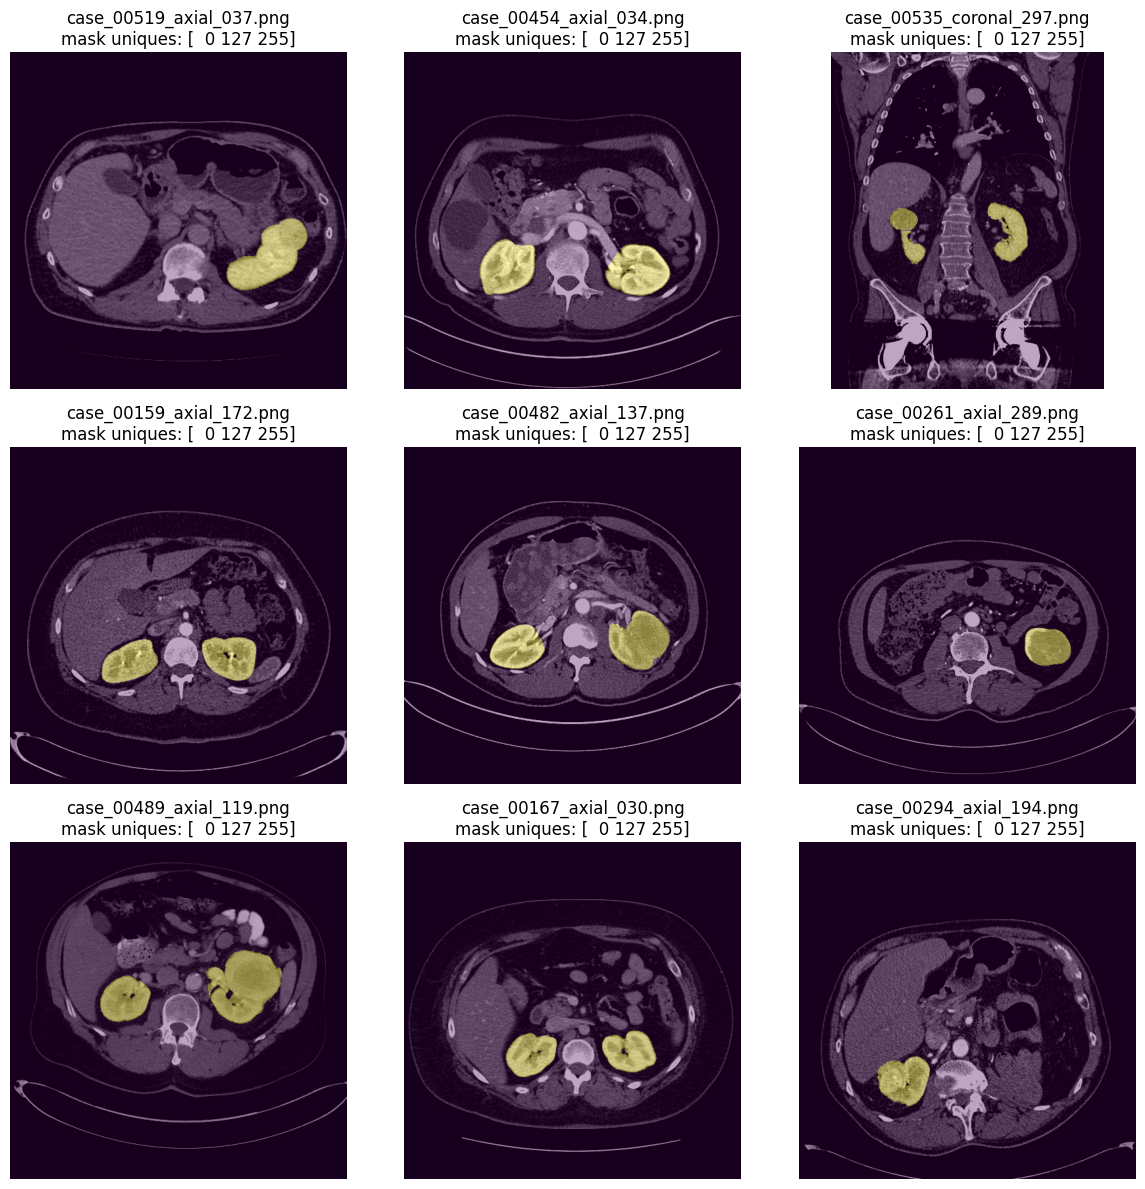

In [7]:
def show_examples(pairs, k=6, seed=0):
    rnd = random.Random(seed)
    chosen = rnd.sample(pairs, k=min(k, len(pairs)))

    cols = 3
    rows = int(np.ceil(len(chosen)/cols))
    plt.figure(figsize=(12, 4*rows))

    for idx, (ip, mp) in enumerate(chosen, start=1):
        im = load_gray(ip)
        mk = np.array(Image.open(mp))

        # Normalize image for display
        im_disp = (im - im.min()) / (im.max() - im.min() + 1e-8)

        plt.subplot(rows, cols, idx)
        plt.imshow(im_disp, cmap="gray")
        plt.imshow((mk > 0).astype(np.float32), alpha=0.35)  # overlay
        plt.title(f"{ip.name}\nmask uniques: {np.unique(mk)[:6]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_examples(split_pairs["train"], k=9, seed=42)

## Cell 8 — Case-level leakage check (optional but strongly recommended)

In [12]:
split_json = Path("F:/projects/hirdl/FedSSL_Paper/data_set/kits_2d_splitted/split_info.json")
if split_json.exists():
    info = json.loads(split_json.read_text())
    train_cases = set(info["train"]["cases"])
    val_cases   = set(info["val"]["cases"])
    test_cases  = set(info["test"]["cases"])

    print("Overlaps:")
    print("train ∩ val :", len(train_cases & val_cases))
    print("train ∩ test:", len(train_cases & test_cases))
    print("val ∩ test  :", len(val_cases & test_cases))
else:
    print("split_info.json not found in project root. Skipping overlap check.")

Overlaps:
train ∩ val : 0
train ∩ test: 0
val ∩ test  : 0


## Cell 9 — Save audit report to outputs/metrics/

In [13]:
audit = {
    "dataset_root": str(DATA_ROOT),
    "split_reports": split_reports,
    "class_balance": balance,
}

out_path = Path("outputs/metrics/dataset_audit.json")
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(json.dumps(audit, indent=2))
print("Saved:", out_path.resolve())

Saved: F:\projects\hirdl\FedSSL_Paper\notebooks\outputs\metrics\dataset_audit.json


# Milestone 1.1

## Cell A — Confirm kidney-only vs tumor slices (per split)

In [14]:
import numpy as np
from PIL import Image
from tqdm import tqdm

KIDNEY_VAL = 127
TUMOR_VAL  = 255

def counts_for_pairs(pairs):
    kidney_only = 0
    tumor_present = 0
    empty = 0
    tumor_pixels_list = []

    for _, mp in tqdm(pairs, leave=False):
        mk = np.array(Image.open(mp))
        has_kidney = (mk == KIDNEY_VAL).any()
        has_tumor  = (mk == TUMOR_VAL).any()

        if not has_kidney and not has_tumor:
            empty += 1
        if has_tumor:
            tumor_present += 1
            tumor_pixels_list.append(int((mk == TUMOR_VAL).sum()))
        elif has_kidney:
            kidney_only += 1

    n = len(pairs)
    tumor_pixels_list = np.array(tumor_pixels_list, dtype=np.int64)

    stats = {
        "n": n,
        "tumor_present": tumor_present,
        "kidney_only": kidney_only,
        "empty_mask": empty,
        "tumor_ratio": tumor_present / n if n else None,
    }
    if tumor_present > 0:
        stats.update({
            "tumor_pixels_min": int(tumor_pixels_list.min()),
            "tumor_pixels_med": int(np.median(tumor_pixels_list)),
            "tumor_pixels_p95": int(np.percentile(tumor_pixels_list, 95)),
            "tumor_pixels_max": int(tumor_pixels_list.max()),
        })
    return stats

split_stats = {s: counts_for_pairs(split_pairs[s]) for s in SPLITS}
pd.DataFrame(split_stats).T

,n,tumor_present,kidney_only,empty_mask,tumor_ratio,tumor_pixels_min,tumor_pixels_med,tumor_pixels_p95,tumor_pixels_max
train,11860.0,11860.0,0.0,0.0,1.0,100.0,1696.0,13220.0,69930.0
val,2309.0,2309.0,0.0,0.0,1.0,100.0,1536.0,10923.0,16298.0
test,3808.0,3808.0,0.0,0.0,1.0,100.0,1679.0,21213.0,30672.0


## Cell B — Update the label function (this becomes our project-wide definition)

In [15]:
def tumor_present_from_mask(mask_arr: np.ndarray) -> bool:
    return (mask_arr == 255).any()

In [18]:
balance = {split: compute_balance(split_pairs[split]) for split in SPLITS}
pd.DataFrame(balance).T

,n,pos,neg,pos_ratio
train,11860.0,11860.0,0.0,1.0
val,2309.0,2309.0,0.0,1.0
test,3808.0,3808.0,0.0,1.0


## Cell C — Visualize tumor-only overlay (not kidney)

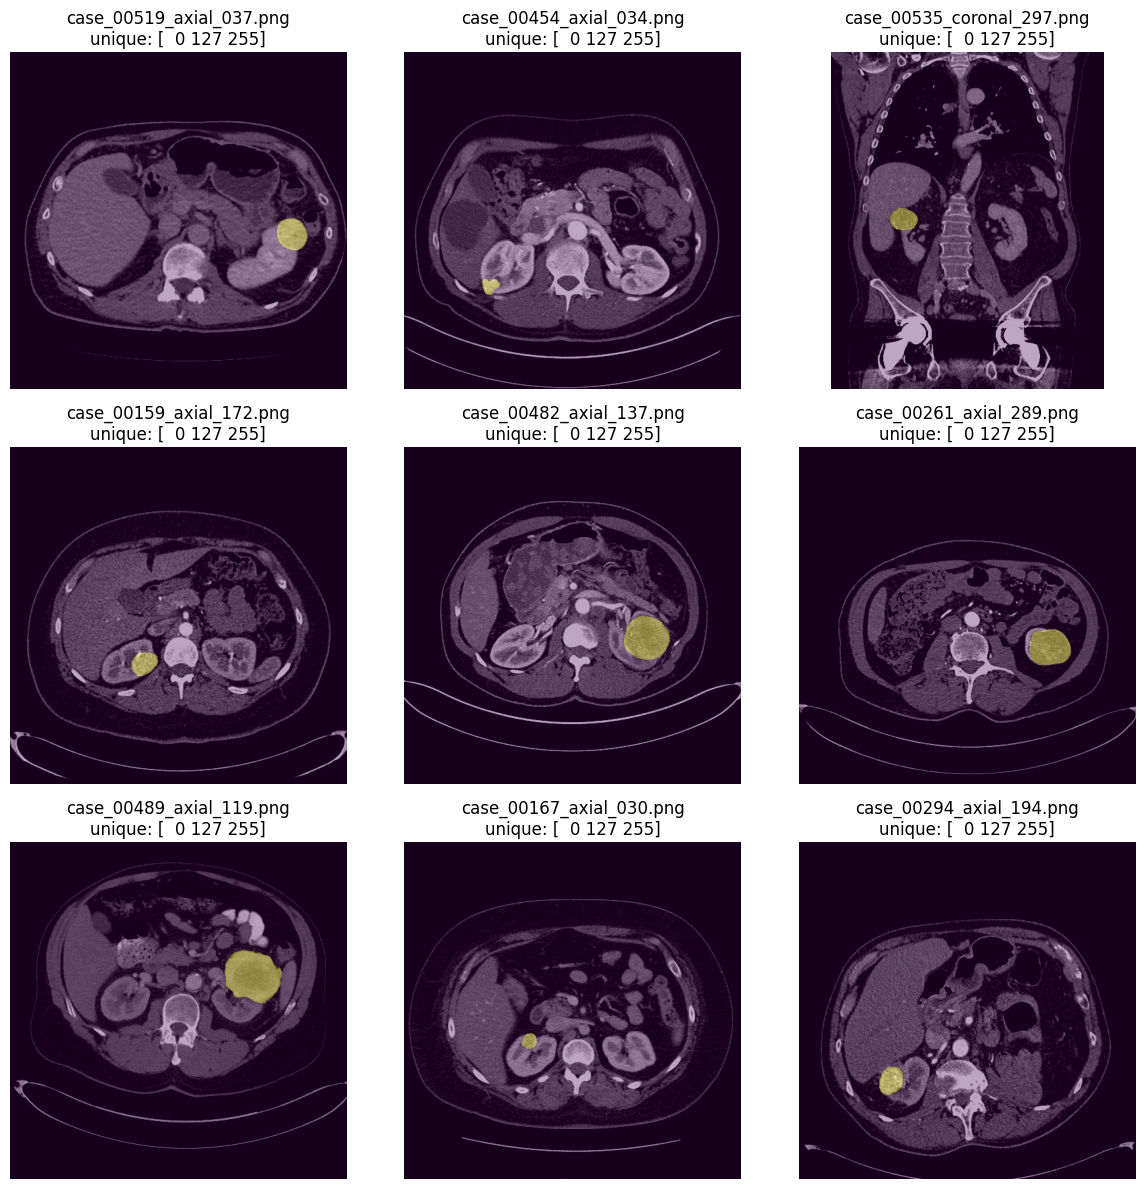

In [19]:
def show_tumor_examples(pairs, k=9, seed=0):
    rnd = random.Random(seed)
    chosen = rnd.sample(pairs, k=min(k, len(pairs)))

    cols = 3
    rows = int(np.ceil(len(chosen)/cols))
    plt.figure(figsize=(12, 4*rows))

    for idx, (ip, mp) in enumerate(chosen, start=1):
        im = np.array(Image.open(ip).convert("L"))
        mk = np.array(Image.open(mp))

        im_disp = (im - im.min()) / (im.max() - im.min() + 1e-8)
        tumor = (mk == 255).astype(np.float32)

        plt.subplot(rows, cols, idx)
        plt.imshow(im_disp, cmap="gray")
        plt.imshow(tumor, alpha=0.35)
        plt.title(f"{ip.name}\nunique: {np.unique(mk)}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_tumor_examples(split_pairs["train"], k=9, seed=42)

# Milestone 2: Build a clean PyTorch Dataset + Transforms (segmentation-ready)